## Accessing Files in the SMCE
#### Author: Rishi Anand

We will use the following libraries to access and analyze data stored in the SMCE.

In [1]:
import copy
import os

import matplotlib.pyplot as plt
import numpy as np
import rioxarray
import s3fs
import xarray as xr

### Check availability

Check that the files are available for the dates of interest, and make sure to understand the file structure.

In [2]:
# Initialize the filesystem to access public s3 buckets
s3 = s3fs.S3FileSystem({'anon':True})

# Check the filenames/availabiity for January of 2015
s3.ls('nasa-waterinsight/NLDAS3/forcing/hourly/201501/')

# Store the url for the file we are interested in plotting
url = 's3://nasa-waterinsight/NLDAS3/forcing/hourly/201501/NLDAS_FOR0010_H.A20150101.030.beta.nc'

In [7]:
# Clip the file to a bounding box
# Format of [Min Long, Min Lat, Max Long, Max Lat]
coords = [
    -121.0, 33.0, -117.0, 35.0
]

In [11]:
# Open the file specified in url and plot a variable in the data
with s3.open(url) as infile:
    print("opening")
    ds = xr.open_dataset(infile, engine="h5netcdf")
    # Set up the coordinate system for rioxarray to cut
    ds.rio.write_crs(4326, inplace=True)
    # Select variable (Tair), hour of day (time=0), and clip
    ds = ds['Tair'].isel(time=0).rio.clip_box(*coords).to_numpy()
    print(np.shape(ds))
    print("done")

opening
(201, 401)
done


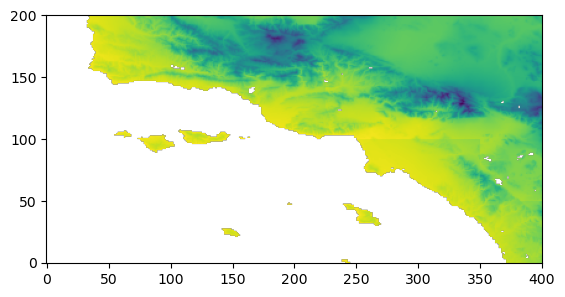

In [12]:
plt.imshow(ds, origin='lower')

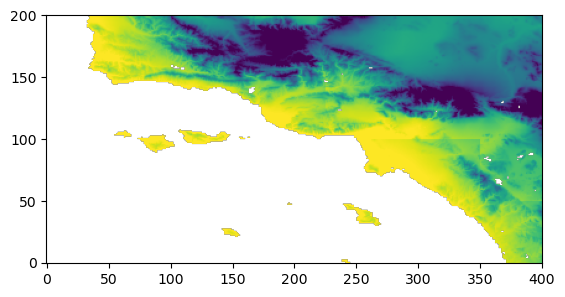

In [18]:
plt.imshow(ds, origin='lower', vmin=270, vmax=285)